# AQI Classification Notebook
## Data Loading, Preprocessing → Part 1: Random Forest → Part 2: XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## 1. Data Loading & Preprocessing

In [2]:
df = pd.read_csv('aqi_data.csv', skipinitialspace=True)
df

,date,pm25,pm10,no2,so2,co
0,2024/8/1,43.0,26.0,73.0,1.0,6.0
1,2024/8/2,45.0,21.0,66.0,1.0,5.0
2,2024/8/3,42.0,22.0,73.0,1.0,4.0
3,2024/8/4,40.0,18.0,96.0,2.0,5.0
4,2024/8/5,37.0,21.0,110.0,1.0,5.0
...,...,...,...,...,...,...
1626,2021/6/28,NaN,13.0,20.0,1.0,4.0
1627,2021/6/29,NaN,28.0,26.0,1.0,5.0
1628,2021/6/30,NaN,31.0,26.0,2.0,4.0
1629,2023/9/26,NaN,NaN,13.0,1.0,8.0


In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_dates = all_dates.difference(df['date'])

print(f"Number of missing dates in sequence: {len(missing_dates)}")
print("First few missing dates:", missing_dates)

Number of missing dates in sequence: 15
First few missing dates: DatetimeIndex(['2020-03-01', '2020-03-23', '2020-03-24', '2020-03-25',
               '2020-03-26', '2020-06-03', '2020-06-04', '2020-06-05',
               '2020-06-06', '2020-06-07', '2020-06-13', '2020-06-14',
               '2020-10-18', '2022-01-07', '2022-01-08'],
              dtype='datetime64[ns]', freq=None)


In [5]:
df_complete = df.set_index('date').reindex(all_dates).rename_axis('date').reset_index()
df_complete

,date,pm25,pm10,no2,so2,co
0,2020-02-10,17.0,NaN,NaN,NaN,NaN
1,2020-02-11,54.0,NaN,NaN,NaN,NaN
2,2020-02-12,167.0,NaN,NaN,NaN,NaN
3,2020-02-13,88.0,NaN,NaN,NaN,NaN
4,2020-02-14,89.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1641,2024-08-08,44.0,NaN,NaN,NaN,NaN
1642,2024-08-09,43.0,40.0,136.0,2.0,4.0
1643,2024-08-10,50.0,18.0,70.0,1.0,3.0
1644,2024-08-11,41.0,21.0,99.0,1.0,5.0


In [6]:
df_complete.isnull().sum()

date      0
pm25    207
pm10    366
no2     716
so2     301
co      292
dtype: int64

In [7]:
numeric_cols = ['pm25', 'pm10', 'no2', 'so2', 'co']
df_filled = df_complete.copy()
df_filled[numeric_cols] = df_filled[numeric_cols].interpolate(method='linear')
df_filled = df_filled.bfill().ffill()
df_filled.isnull().sum()

date    0
pm25    0
pm10    0
no2     0
so2     0
co      0
dtype: int64

In [8]:
df_filled

,date,pm25,pm10,no2,so2,co
0,2020-02-10,17.0,41.000000,1.000000,30.000000,2.000000
1,2020-02-11,54.0,41.000000,1.000000,30.000000,2.000000
2,2020-02-12,167.0,41.000000,1.000000,30.000000,2.000000
3,2020-02-13,88.0,41.000000,1.000000,30.000000,2.000000
4,2020-02-14,89.0,41.000000,1.000000,30.000000,2.000000
...,...,...,...,...,...,...
1641,2024-08-08,44.0,32.666667,121.333333,1.666667,3.666667
1642,2024-08-09,43.0,40.000000,136.000000,2.000000,4.000000
1643,2024-08-10,50.0,18.000000,70.000000,1.000000,3.000000
1644,2024-08-11,41.0,21.000000,99.000000,1.000000,5.000000


### 1.1 Convert Pollutant Concentrations to AQI (US-EPA)

In [9]:
def calculate_aqi_p(cp, pollutant):
    breakpoints = {
        'pm25': [
            (0.0, 12.0, 0, 50), (12.1, 35.4, 51, 100), (35.5, 55.4, 101, 150),
            (55.5, 150.4, 151, 200), (150.5, 250.4, 201, 300), (250.5, 500.4, 301, 500)
        ],
        'pm10': [
            (0, 54, 0, 50), (55, 154, 51, 100), (155, 254, 101, 150),
            (255, 354, 151, 200), (355, 424, 201, 300), (425, 604, 301, 500)
        ],
        'no2': [
            (0, 53, 0, 50), (54, 100, 51, 100), (101, 360, 101, 150),
            (361, 649, 151, 200), (650, 1249, 201, 300), (1250, 2049, 301, 500)
        ],
        'so2': [
            (0, 35, 0, 50), (36, 75, 51, 100), (76, 185, 101, 150),
            (186, 304, 151, 200), (305, 604, 201, 300), (605, 1004, 301, 500)
        ],
        'co': [
            (0.0, 4.4, 0, 50), (4.5, 9.4, 51, 100), (9.5, 12.4, 101, 150),
            (12.5, 15.4, 151, 200), (15.5, 30.4, 201, 300), (30.5, 50.4, 301, 500)
        ]
    }

    if pollutant not in breakpoints: return np.nan
    if pd.isna(cp) or cp < 0: return np.nan

    for (bplo, bphi, ilo, ihi) in breakpoints[pollutant]:
        if bplo <= cp <= bphi:
            aqi = ((ihi - ilo) / (bphi - bplo)) * (cp - bplo) + ilo
            return round(aqi)

    return 500

In [10]:
df_filled['aqi_pm25'] = df_filled['pm25'].apply(lambda x: calculate_aqi_p(x, 'pm25'))
df_filled['aqi_pm10'] = df_filled['pm10'].apply(lambda x: calculate_aqi_p(x, 'pm10'))
df_filled['aqi_no2']  = df_filled['no2'].apply(lambda x: calculate_aqi_p(x, 'no2'))
df_filled['aqi_so2']  = df_filled['so2'].apply(lambda x: calculate_aqi_p(x, 'so2'))
df_filled['aqi_co']   = df_filled['co'].apply(lambda x: calculate_aqi_p(x, 'co'))

df_filled['final_aqi'] = df_filled[['aqi_pm25', 'aqi_pm10', 'aqi_no2', 'aqi_so2', 'aqi_co']].max(axis=1)

def get_status(aqi):
    if aqi <= 50:  return "Good"
    if aqi <= 100: return "Moderate"
    if aqi <= 150: return "Unhealthy for Sensitive Groups"
    if aqi <= 200: return "Unhealthy"
    return "Very Unhealthy / Hazardous"

df_filled['aqi_status'] = df_filled['final_aqi'].apply(get_status)
print(df_filled[['date', 'final_aqi', 'aqi_status']].head())

        date  final_aqi                      aqi_status
0 2020-02-10         61                        Moderate
1 2020-02-11        147  Unhealthy for Sensitive Groups
2 2020-02-12        217      Very Unhealthy / Hazardous
3 2020-02-13        168                       Unhealthy
4 2020-02-14        168                       Unhealthy


In [11]:
df_filled = df_filled.drop(columns=['aqi_pm25','aqi_pm10', 'aqi_no2', 'aqi_so2', 'aqi_co'])
df_filled

,date,pm25,pm10,no2,so2,co,final_aqi,aqi_status
0,2020-02-10,17.0,41.000000,1.000000,30.000000,2.000000,61,Moderate
1,2020-02-11,54.0,41.000000,1.000000,30.000000,2.000000,147,Unhealthy for Sensitive Groups
2,2020-02-12,167.0,41.000000,1.000000,30.000000,2.000000,217,Very Unhealthy / Hazardous
3,2020-02-13,88.0,41.000000,1.000000,30.000000,2.000000,168,Unhealthy
4,2020-02-14,89.0,41.000000,1.000000,30.000000,2.000000,168,Unhealthy
...,...,...,...,...,...,...,...,...
1641,2024-08-08,44.0,32.666667,121.333333,1.666667,3.666667,122,Unhealthy for Sensitive Groups
1642,2024-08-09,43.0,40.000000,136.000000,2.000000,4.000000,119,Unhealthy for Sensitive Groups
1643,2024-08-10,50.0,18.000000,70.000000,1.000000,3.000000,137,Unhealthy for Sensitive Groups
1644,2024-08-11,41.0,21.000000,99.000000,1.000000,5.000000,115,Unhealthy for Sensitive Groups


In [12]:
numeric_cols.append('final_aqi')

### 1.2 Exploratory Data Analysis

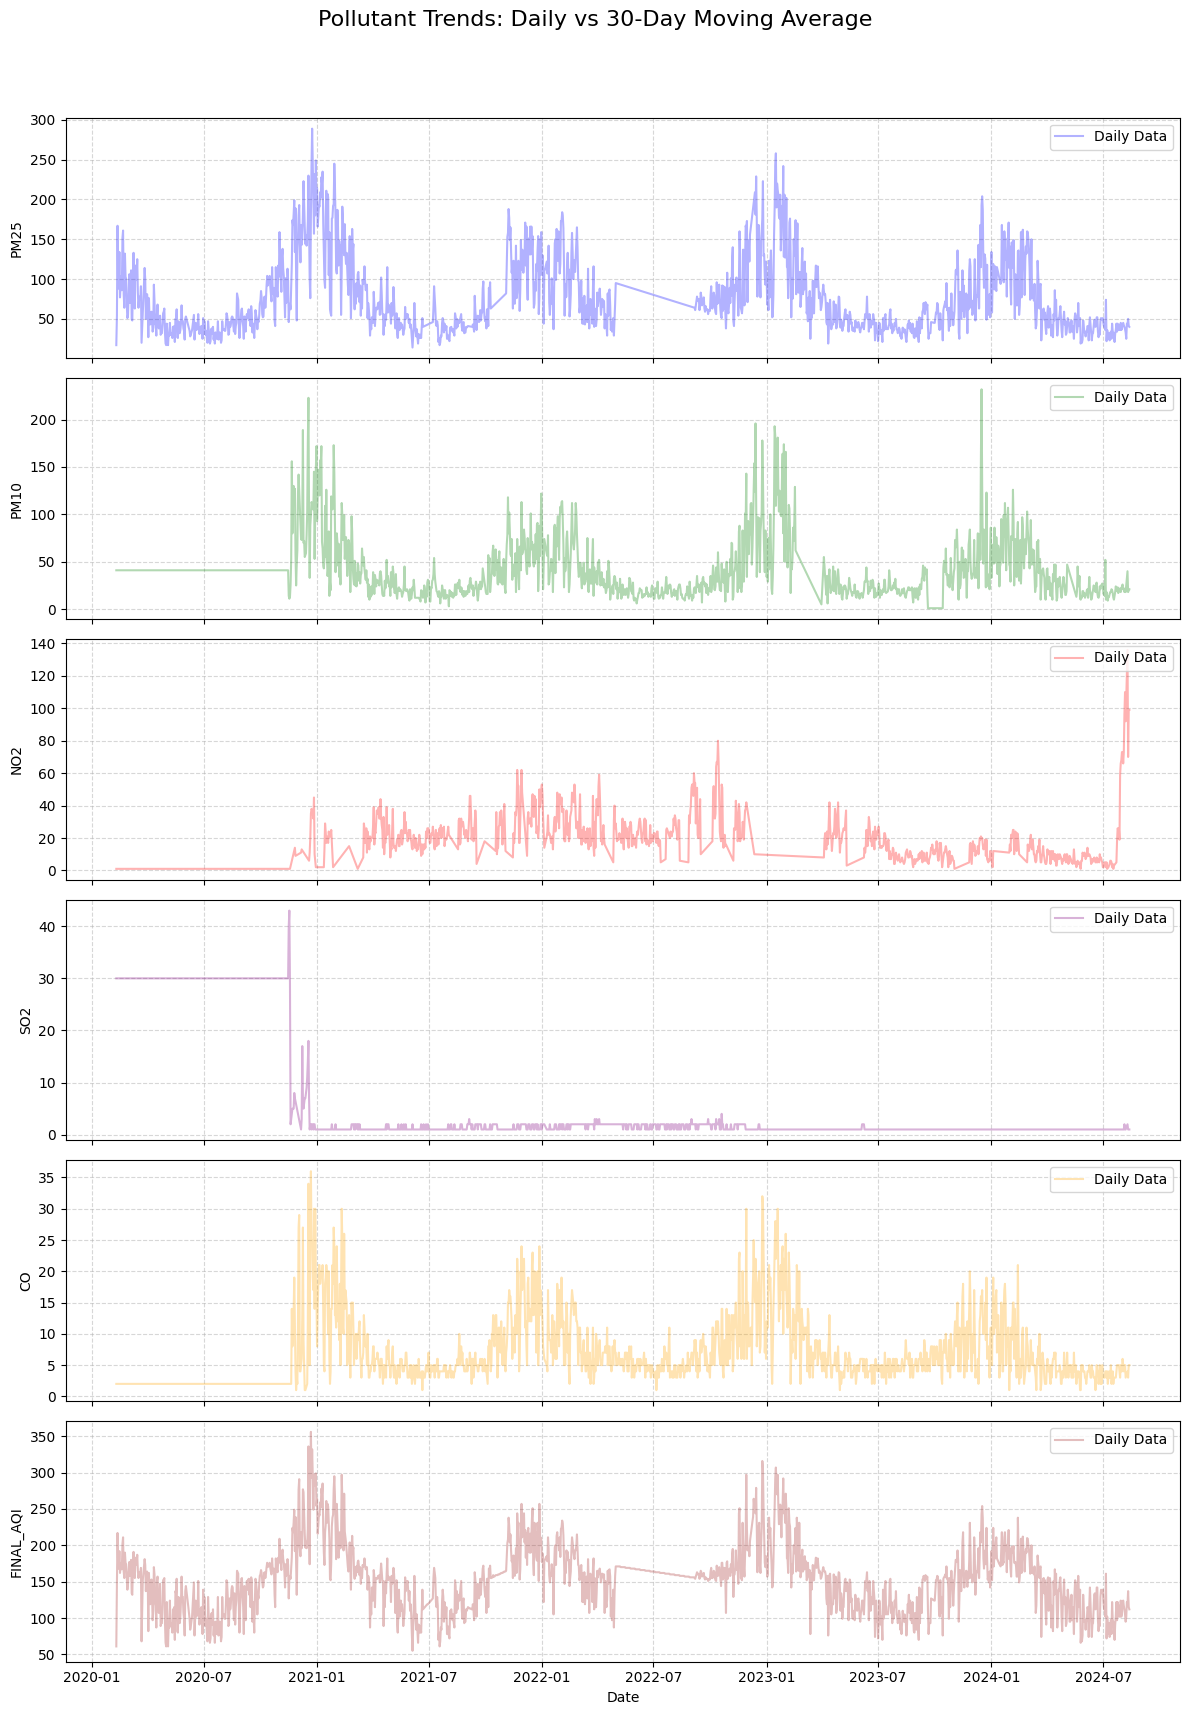

In [13]:
fig, axes = plt.subplots(6, 1, figsize=(12, 18), sharex=True)
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

for i, col in enumerate(numeric_cols):
    axes[i].plot(df_filled['date'], df_filled[col], color=colors[i], alpha=0.3, label='Daily Data')
    axes[i].set_ylabel(col.upper())
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date')
plt.suptitle('Pollutant Trends: Daily vs 30-Day Moving Average', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/var/folders/hd/hqx41svd20lcfdp6nt85c0j80000gn/T/ipykernel_16608/757307735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Pollutant', y='Concentration', palette='Set2')


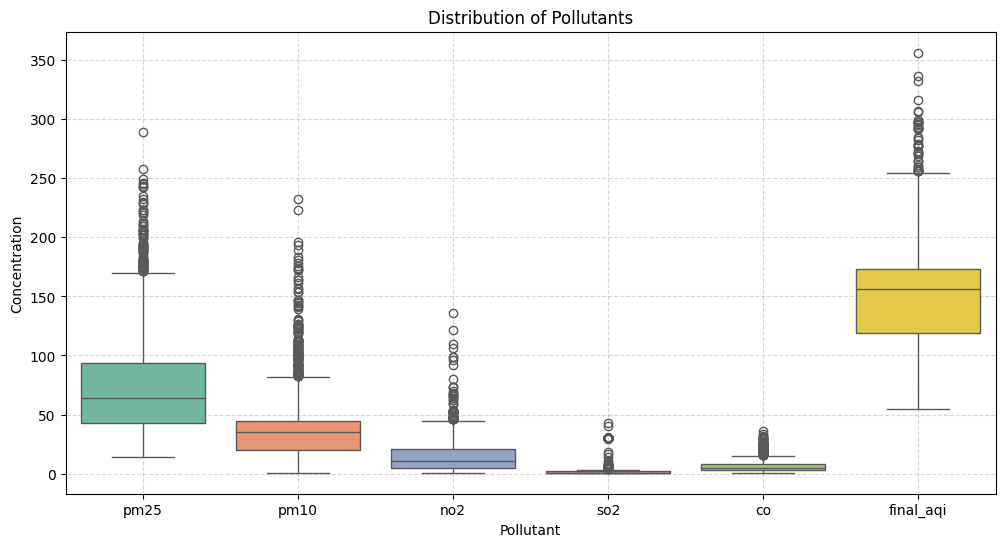

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
df_plot = df_filled[numeric_cols].melt(var_name='Pollutant', value_name='Concentration')
sns.boxplot(data=df_plot, x='Pollutant', y='Concentration', palette='Set2')
plt.title('Distribution of Pollutants')
plt.ylabel('Concentration')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

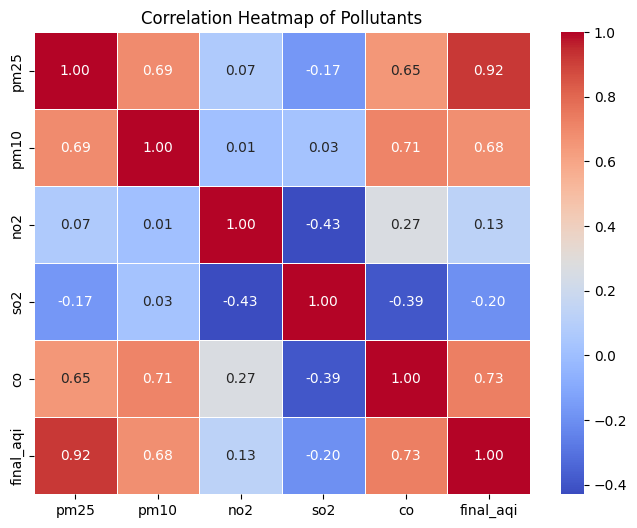

In [15]:
plt.figure(figsize=(8, 6))
correlation = df_filled[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Pollutants')
plt.show()

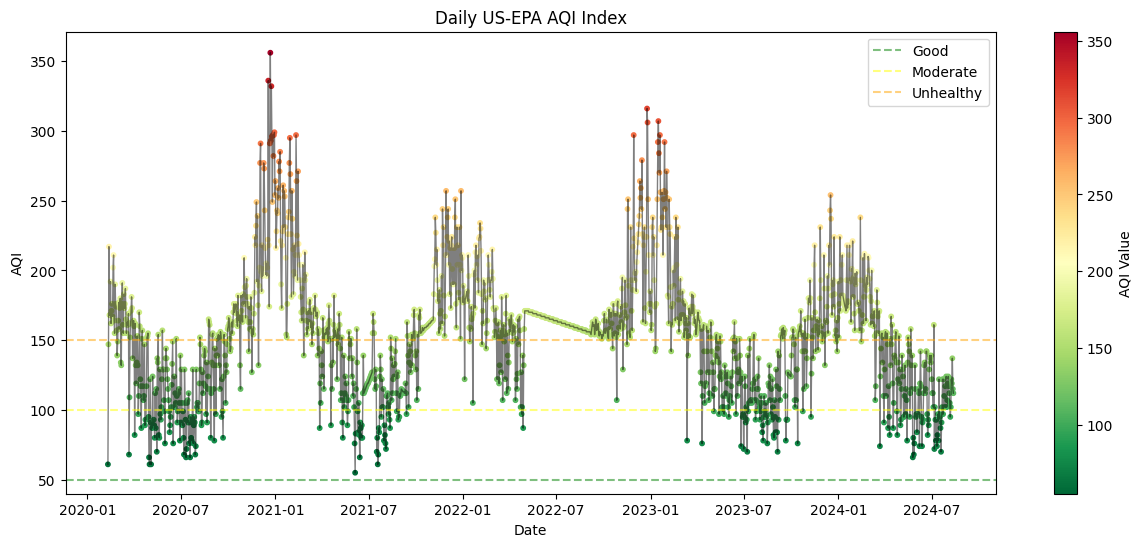

In [16]:
plt.figure(figsize=(15, 6))
plt.plot(df_filled['date'], df_filled['final_aqi'], color='black', linewidth=1, alpha=0.5)
plt.scatter(df_filled['date'], df_filled['final_aqi'], c=df_filled['final_aqi'], cmap='RdYlGn_r', s=10)
plt.axhline(50,  color='green',  linestyle='--', alpha=0.5, label='Good')
plt.axhline(100, color='yellow', linestyle='--', alpha=0.5, label='Moderate')
plt.axhline(150, color='orange', linestyle='--', alpha=0.5, label='Unhealthy')
plt.title('Daily US-EPA AQI Index')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend(loc='upper right')
plt.colorbar(label='AQI Value')
plt.show()

### 1.3 Feature Engineering & Train/Test Split

In [17]:
df_filled['month']      = df_filled['date'].dt.month
df_filled['dayofweek']  = df_filled['date'].dt.dayofweek
df_filled['is_weekend'] = (df_filled['dayofweek'] >= 5).astype(int)

# Note: pm25 excluded — it is the dominant driver of final_aqi (high collinearity with target)
FEATURE_COLS = ['pm10', 'no2', 'so2', 'co', 'month', 'dayofweek', 'is_weekend']
TARGET_COL   = 'aqi_status'

X = df_filled[FEATURE_COLS]
y = df_filled[TARGET_COL]

print("Class distribution:")
print(y.value_counts())

Class distribution:
aqi_status
Unhealthy                         776
Unhealthy for Sensitive Groups    461
Very Unhealthy / Hazardous        205
Moderate                          204
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 1316  |  Test size: 330


In [19]:
# Quick sanity check
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())
print(f"X shape: {X.shape} | y shape: {y.shape}")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

Missing values in X: 0
Missing values in y: 0
X shape: (1646, 7) | y shape: (1646,)
X_train: (1316, 7) | X_test: (330, 7)


---
## Part 1 — Random Forest
Two variants trained with **GridSearchCV** over explicit parameter combinations:
- **RF with Class Weights**
- **RF with SMOTE**

### 1a. Random Forest — Class Weights

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import label_binarize
import numpy as np

classes_rf        = np.unique(y_train)
weights_rf        = compute_class_weight('balanced', classes=classes_rf, y=y_train)
class_weight_dict = dict(zip(classes_rf, weights_rf))

# --- Parameter grid ---
param_grid_rf = {
    'n_estimators':      [100, 300, 500],
    'max_depth':         [None, 10, 20],
    'max_leaf_nodes':    [20, 30, 40],
    'min_samples_split': [2, 5, 10]
}

rf_cv = GridSearchCV(
    RandomForestClassifier(class_weight=class_weight_dict, random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
rf_cv.fit(X_train, y_train)

print("Best params (RF Class Weights):", rf_cv.best_params_)
print(f"Best CV f1_macro: {rf_cv.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params (RF Class Weights): {'max_depth': 10, 'max_leaf_nodes': 40, 'min_samples_split': 10, 'n_estimators': 100}
Best CV f1_macro: 0.6014


In [21]:
rf           = rf_cv.best_estimator_
y_pred_rf    = rf.predict(X_test)

print("=== Random Forest (Class Weights) ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest (Class Weights) ===
                                precision    recall  f1-score   support

                      Moderate       0.35      0.59      0.44        41
                     Unhealthy       0.75      0.60      0.67       156
Unhealthy for Sensitive Groups       0.42      0.34      0.38        92
    Very Unhealthy / Hazardous       0.56      0.85      0.68        41

                      accuracy                           0.56       330
                     macro avg       0.52      0.59      0.54       330
                  weighted avg       0.58      0.56      0.56       330



### 1b. Random Forest — SMOTE

In [22]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Parameter grid (step prefix: rf__) ---
param_grid_rf_smote = {
    'smote__k_neighbors':    [3, 5],
    'rf__n_estimators':      [100, 300, 500],
    'rf__max_depth':         [None, 10, 20],
    'rf__max_leaf_nodes':    [20, 30, 40],
    'rf__min_samples_split': [2, 5, 10]
}

base_rf_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf',    RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_smote_cv = GridSearchCV(
    base_rf_smote,
    param_grid=param_grid_rf_smote,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
rf_smote_cv.fit(X_train, y_train)

print("Best params (RF + SMOTE):", rf_smote_cv.best_params_)
print(f"Best CV f1_macro: {rf_smote_cv.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params (RF + SMOTE): {'rf__max_depth': 10, 'rf__max_leaf_nodes': 40, 'rf__min_samples_split': 10, 'rf__n_estimators': 300, 'smote__k_neighbors': 3}
Best CV f1_macro: 0.6102


In [23]:
pipeline_rf       = rf_smote_cv.best_estimator_
y_pred_rf_smote   = pipeline_rf.predict(X_test)

print("=== Random Forest + SMOTE ===")
print(classification_report(y_test, y_pred_rf_smote))

=== Random Forest + SMOTE ===
                                precision    recall  f1-score   support

                      Moderate       0.36      0.63      0.46        41
                     Unhealthy       0.73      0.62      0.67       156
Unhealthy for Sensitive Groups       0.45      0.32      0.37        92
    Very Unhealthy / Hazardous       0.57      0.83      0.67        41

                      accuracy                           0.56       330
                     macro avg       0.53      0.60      0.54       330
                  weighted avg       0.58      0.56      0.56       330



### 1c. Random Forest — Confusion Matrices

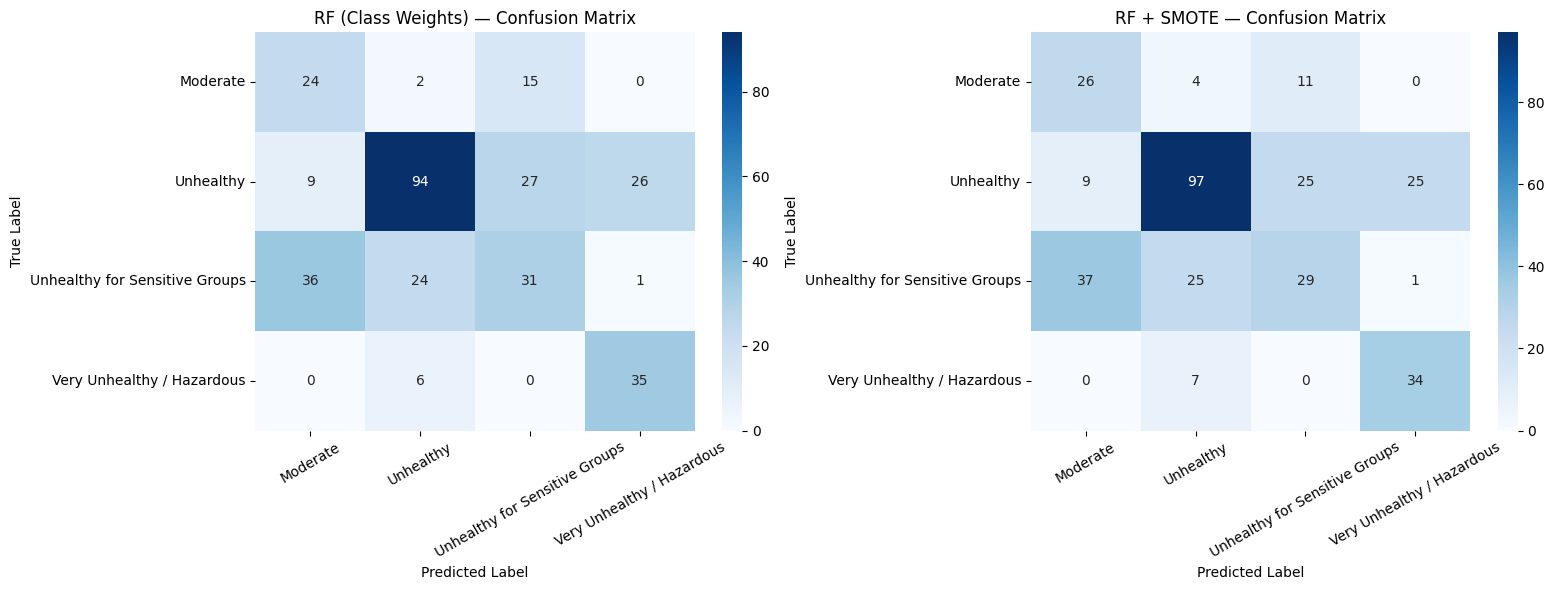

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

class_labels = sorted(y.unique())

cm_rf       = confusion_matrix(y_test, y_pred_rf,       labels=class_labels)
cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote, labels=class_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title('RF (Class Weights) — Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_rf_smote, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels)
axes[1].set_title('RF + SMOTE — Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 1d. Random Forest — ROC Curves & AUC

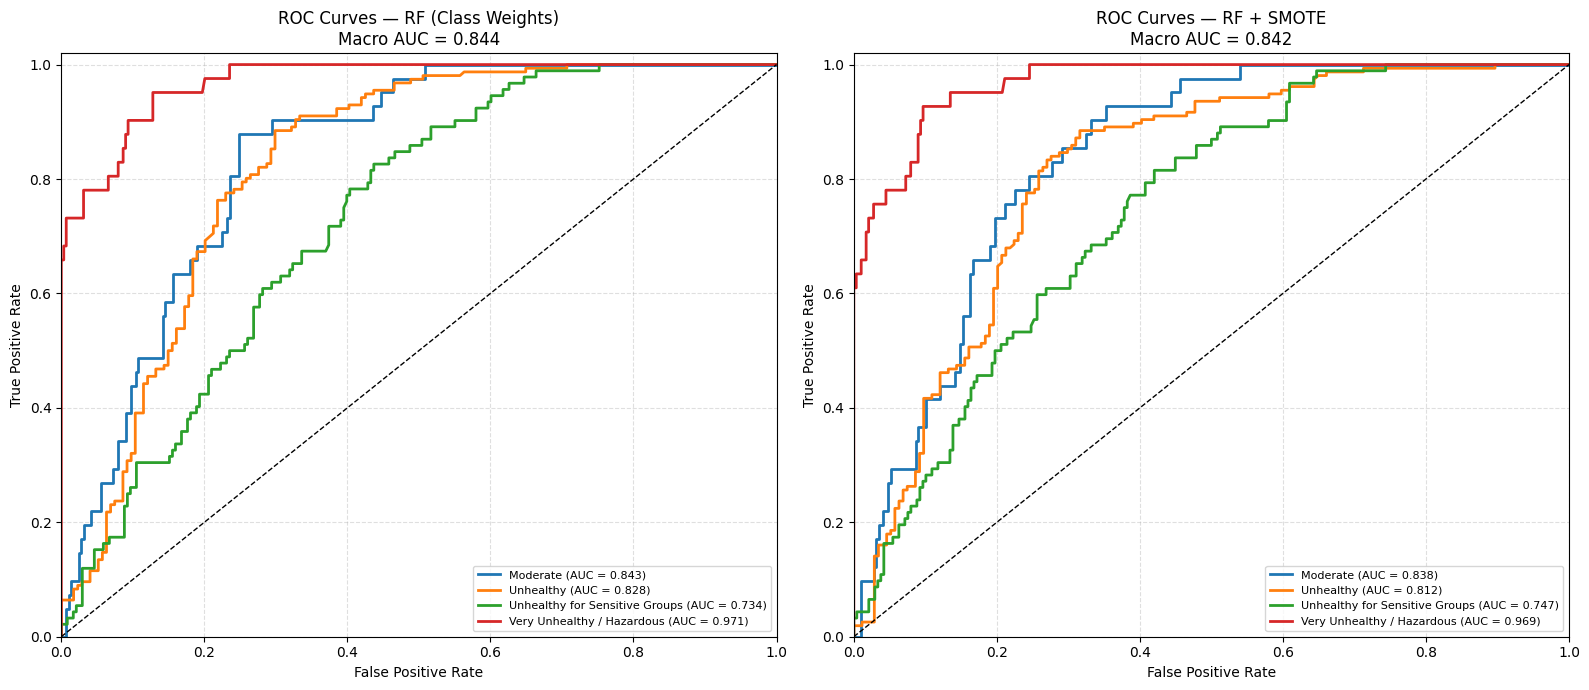

In [25]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=class_labels)

# Predicted probabilities
y_prob_rf       = rf.predict_proba(X_test)
y_prob_rf_smote = pipeline_rf.predict_proba(X_test)

# Reorder proba columns to match class_labels order
rf_classes       = list(rf.classes_)
rf_smote_classes = list(pipeline_rf.classes_)

def reorder_proba(proba, model_classes, target_classes):
    idx = [model_classes.index(c) for c in target_classes]
    return proba[:, idx]

y_prob_rf       = reorder_proba(y_prob_rf,       rf_classes,       class_labels)
y_prob_rf_smote = reorder_proba(y_prob_rf_smote, rf_smote_classes, class_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = plt.cm.tab10.colors

for ax, y_prob, title in zip(
    axes,
    [y_prob_rf, y_prob_rf_smote],
    ['RF (Class Weights)', 'RF + SMOTE']
):
    auc_scores = []
    for i, cls in enumerate(class_labels):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        ax.plot(fpr, tpr, color=colors[i], lw=2,
                label=f'{cls} (AUC = {roc_auc:.3f})')
    ax.plot([0,1],[0,1], 'k--', lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {title}\nMacro AUC = {np.mean(auc_scores):.3f}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 1e. Random Forest — Feature Importance

/var/folders/hd/hqx41svd20lcfdp6nt85c0j80000gn/T/ipykernel_16608/1615878731.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


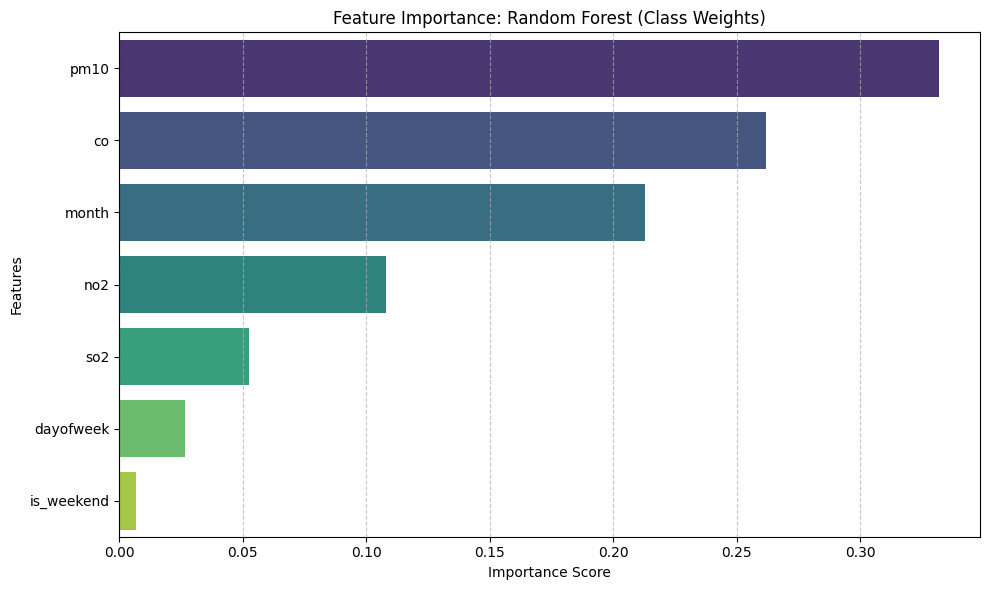

/var/folders/hd/hqx41svd20lcfdp6nt85c0j80000gn/T/ipykernel_16608/1615878731.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


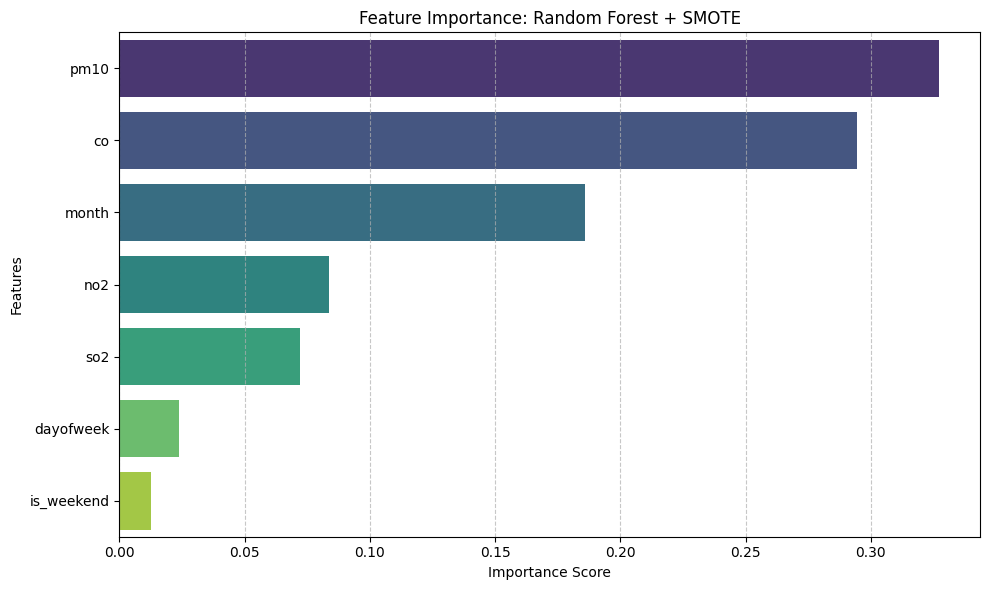

In [26]:
def plot_feature_importance(model, feature_names, title):
    importances = model.feature_importances_
    fi_df = (
        __import__('pandas').DataFrame({'Feature': feature_names, 'Importance': importances})
        .sort_values('Importance', ascending=False)
    )
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
    plt.title(f'Feature Importance: {title}')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_feature_importance(rf,                             FEATURE_COLS, 'Random Forest (Class Weights)')
plot_feature_importance(pipeline_rf.named_steps['rf'],  FEATURE_COLS, 'Random Forest + SMOTE')

---
## Part 2 — XGBoost
Two variants trained with **GridSearchCV** over explicit parameter combinations:
- **XGBoost with Sample Weights**
- **XGBoost with SMOTE**

### 2a. XGBoost — Sample Weights

In [27]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

from sklearn.utils.class_weight import compute_class_weight
weights_xgb    = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
sample_weights = np.array([weights_xgb[i] for i in y_train_enc])

# --- Parameter grid ---
param_grid_xgb = {
    'n_estimators':    [100, 300, 500],
    'max_depth':       [4, 8, 12],
    'learning_rate':   [0.01, 0.1, 0.2],
    'min_child_weight':[1, 5, 10],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0]
}

xgb_cv = GridSearchCV(
    xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
xgb_cv.fit(X_train, y_train_enc, sample_weight=sample_weights)

print("Best params (XGBoost Sample Weights):", xgb_cv.best_params_)
print(f"Best CV f1_macro: {xgb_cv.best_score_:.4f}")

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best params (XGBoost Sample Weights): {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 100, 'subsample': 0.7}
Best CV f1_macro: 0.6540


In [28]:
xgb_model         = xgb_cv.best_estimator_
y_pred_xgb        = xgb_model.predict(X_test)
y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)

print("=== XGBoost (Sample Weights) ===")
print(classification_report(y_test, y_pred_xgb_labels))

=== XGBoost (Sample Weights) ===
                                precision    recall  f1-score   support

                      Moderate       0.36      0.61      0.45        41
                     Unhealthy       0.75      0.60      0.67       156
Unhealthy for Sensitive Groups       0.43      0.40      0.42        92
    Very Unhealthy / Hazardous       0.67      0.80      0.73        41

                      accuracy                           0.57       330
                     macro avg       0.55      0.60      0.57       330
                  weighted avg       0.60      0.57      0.58       330



### 2b. XGBoost — SMOTE

In [29]:
# --- Parameter grid (step prefix: xgb__) ---
param_grid_xgb_smote = {
    'smote__k_neighbors':    [3, 5],
    'xgb__n_estimators':     [100, 300, 500],
    'xgb__max_depth':        [4, 8, 12],
    'xgb__learning_rate':    [0.01, 0.1, 0.2],
    'xgb__min_child_weight': [1, 5, 10],
    'xgb__subsample':        [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0]
}

base_xgb_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb',   xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1))
])

xgb_smote_cv = GridSearchCV(
    base_xgb_smote,
    param_grid=param_grid_xgb_smote,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
xgb_smote_cv.fit(X_train, y_train_enc)

print("Best params (XGBoost + SMOTE):", xgb_smote_cv.best_params_)
print(f"Best CV f1_macro: {xgb_smote_cv.best_score_:.4f}")

Fitting 5 folds for each of 1458 candidates, totalling 7290 fits


KeyboardInterrupt: 

In [ ]:
pipeline_xgb             = xgb_smote_cv.best_estimator_
y_pred_xgb_smote         = pipeline_xgb.predict(X_test)
y_pred_xgb_smote_labels  = le.inverse_transform(y_pred_xgb_smote)

print("=== XGBoost + SMOTE ===")
print(classification_report(y_test, y_pred_xgb_smote_labels))

### 2c. XGBoost — Confusion Matrices

In [ ]:
cm_xgb       = confusion_matrix(y_test, y_pred_xgb_labels,       labels=class_labels)
cm_xgb_smote = confusion_matrix(y_test, y_pred_xgb_smote_labels, labels=class_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title('XGBoost (Sample Weights) — Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_xgb_smote, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels)
axes[1].set_title('XGBoost + SMOTE — Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2d. XGBoost — ROC Curves & AUC

In [ ]:
# Predicted probabilities (XGBoost outputs in encoded label order)
y_prob_xgb       = xgb_model.predict_proba(X_test)
y_prob_xgb_smote = pipeline_xgb.predict_proba(X_test)

# Map encoded class order → original class_labels order
enc_classes = list(le.classes_)   # original string labels in LabelEncoder order

def reorder_proba_le(proba, enc_classes, target_classes):
    idx = [enc_classes.index(c) for c in target_classes]
    return proba[:, idx]

y_prob_xgb       = reorder_proba_le(y_prob_xgb,       enc_classes, class_labels)
y_prob_xgb_smote = reorder_proba_le(y_prob_xgb_smote, enc_classes, class_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, y_prob, title in zip(
    axes,
    [y_prob_xgb, y_prob_xgb_smote],
    ['XGBoost (Sample Weights)', 'XGBoost + SMOTE']
):
    auc_scores = []
    for i, cls in enumerate(class_labels):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        ax.plot(fpr, tpr, color=colors[i], lw=2,
                label=f'{cls} (AUC = {roc_auc:.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {title}\nMacro AUC = {np.mean(auc_scores):.3f}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 2e. XGBoost — Feature Importance

In [ ]:
plot_feature_importance(xgb_model,                            FEATURE_COLS, 'XGBoost (Sample Weights)')
plot_feature_importance(pipeline_xgb.named_steps['xgb'],      FEATURE_COLS, 'XGBoost + SMOTE')

---
## Summary — Model Comparison

In [ ]:
import pandas as pd

# AUC per model (macro average over classes)
def macro_auc(y_test_bin, y_prob, class_labels):
    scores = [auc(*roc_curve(y_test_bin[:, i], y_prob[:, i])[:2])
              for i in range(len(class_labels))]
    return round(np.mean(scores), 4)

summary = pd.DataFrame({
    'Model': [
        'Random Forest (Class Weights)',
        'Random Forest + SMOTE',
        'XGBoost (Sample Weights)',
        'XGBoost + SMOTE'
    ],
    'Best CV f1_macro': [
        round(rf_cv.best_score_, 4),
        round(rf_smote_cv.best_score_, 4),
        round(xgb_cv.best_score_, 4),
        round(xgb_smote_cv.best_score_, 4)
    ],
    'Test Macro AUC': [
        macro_auc(y_test_bin, y_prob_rf,       class_labels),
        macro_auc(y_test_bin, y_prob_rf_smote, class_labels),
        macro_auc(y_test_bin, y_prob_xgb,      class_labels),
        macro_auc(y_test_bin, y_prob_xgb_smote,class_labels)
    ],
    'Best Params': [
        str(rf_cv.best_params_),
        str(rf_smote_cv.best_params_),
        str(xgb_cv.best_params_),
        str(xgb_smote_cv.best_params_)
    ]
}).sort_values('Test Macro AUC', ascending=False).reset_index(drop=True)

summary